# Unsupervised Analysis

This notebook evaluates the structure of the preprocessed lamproite geochemical dataset using unsupervised multivariate methods. Principal component analysis is performed first using the log transformed and Z score standardised dataset.

In [1]:
# =============================================================================
# Environment setup
# =============================================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

ROOT_DIR = Path.cwd().parent

DATA_DIR = ROOT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
EXPORT_DIR = ROOT_DIR / "exports"
FIGURE_DIR = ROOT_DIR / "figures"

EXPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 99

print("Environment initialised.")
print(f"Root directory   : {ROOT_DIR}")
print(f"Processed data   : {PROCESSED_DIR}")
print(f"Export directory : {EXPORT_DIR}")
print(f"Figure directory : {FIGURE_DIR}")

Environment initialised.
Root directory   : C:\Users\d67199rs\Desktop\Lamproite
Processed data   : C:\Users\d67199rs\Desktop\Lamproite\data\processed
Export directory : C:\Users\d67199rs\Desktop\Lamproite\exports
Figure directory : C:\Users\d67199rs\Desktop\Lamproite\figures


## 1. Load Preprocessed Dataset

Load the log transformed and Z score standardised modelling dataset and evaluate the explained variance of the principal components to determine the number of components required to capture the majority of the dataset variance.

In [4]:
# =============================================================================
# Load preprocessed dataset
# =============================================================================

DATA_FILE = PROCESSED_DIR / "Modelling_Dataset_Log_ZScaled.csv"

df = pd.read_csv(DATA_FILE, encoding="utf-8")

META = ["Series", "Location", "Rock Type"]
ELEMENTS = [c for c in df.columns if c not in META]

X = df[ELEMENTS]

print("Preprocessed dataset loaded.")

Preprocessed dataset loaded.


## 2. Principal Component Analysis

Fit a principal component analysis using all retained trace elements and evaluate the explained and cumulative variance to determine the number of principal components retained for subsequent analyses.

In [3]:
# =============================================================================
# Principal component analysis
# =============================================================================

pca = PCA(random_state=RANDOM_STATE)
scores = pca.fit_transform(X)

explained_variance = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(ELEMENTS))],
    "ExplainedVariance(%)": np.round(pca.explained_variance_ratio_ * 100, 2),
    "CumulativeVariance(%)": np.round(np.cumsum(pca.explained_variance_ratio_) * 100, 2)
})

display(explained_variance)

,Component,ExplainedVariance(%),CumulativeVariance(%)
0,PC1,40.30,40.30
1,PC2,19.23,59.53
2,PC3,11.26,70.79
3,PC4,8.35,79.14
4,PC5,5.43,84.57
5,PC6,4.85,89.41
6,PC7,3.63,93.04
7,PC8,2.61,95.65
8,PC9,1.90,97.55
9,PC10,1.53,99.08


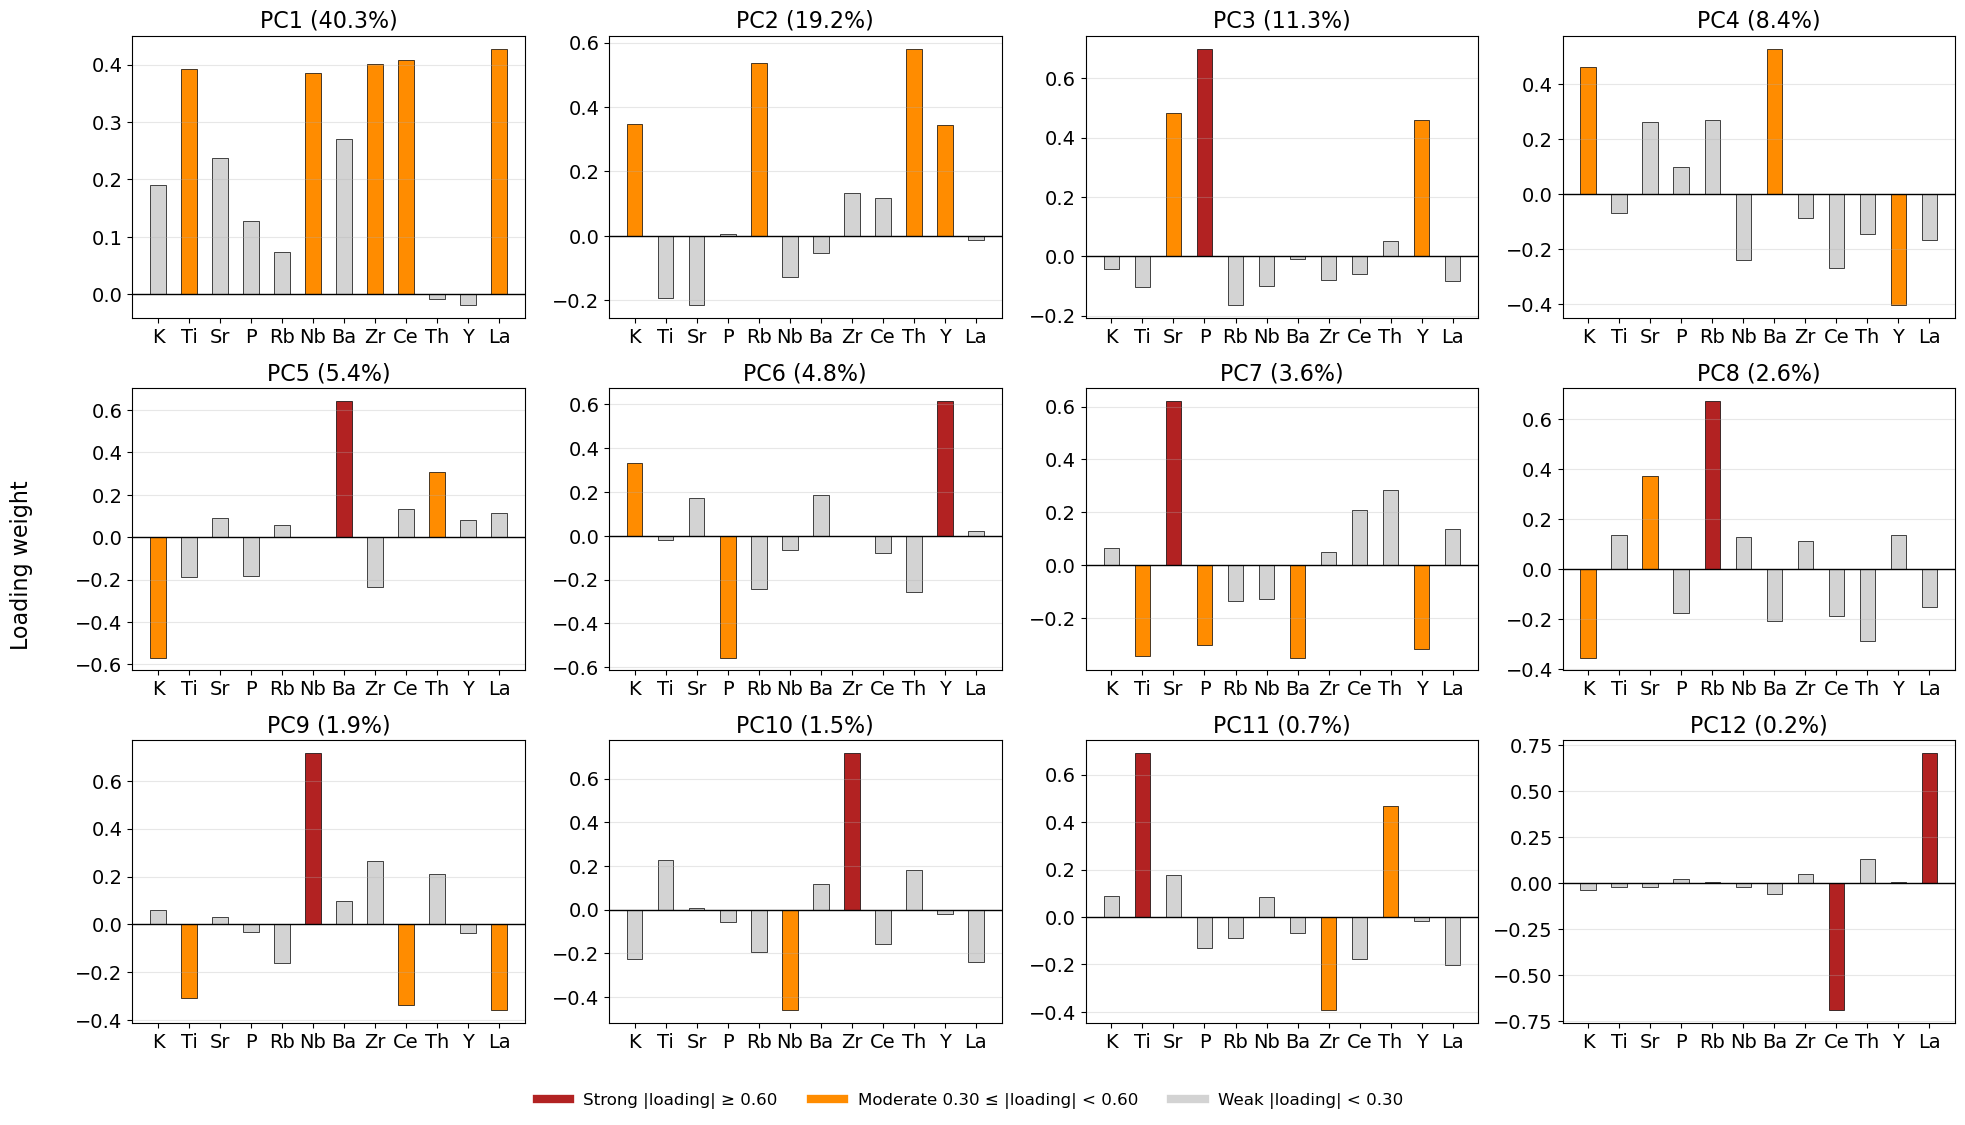

Saved figure : C:\Users\d67199rs\Desktop\Lamproite\figures\07_PCA_Loading_Plots.png
Saved table  : C:\Users\d67199rs\Desktop\Lamproite\exports\05_PCA_Loadings.csv


In [12]:
# =============================================================================
# PCA loading plots
# =============================================================================

loadings = pd.DataFrame(pca.components_.T, index=ELEMENTS, columns=[f"PC{i+1}" for i in range(len(ELEMENTS))])
loadings.round(4).to_csv(EXPORT_DIR / "05_PCA_Loadings.csv")

ncols = 4
nrows = int(np.ceil(loadings.shape[1] / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.8*nrows))
axes = np.array(axes).flatten()

for ax, pc in zip(axes, loadings.columns):
    values = loadings[pc]
    colours = ["firebrick" if abs(v) >= 0.60 else "darkorange" if abs(v) >= 0.30 else "lightgrey" for v in values]

    ax.bar(ELEMENTS, values, color=colours, edgecolor="black", linewidth=0.5,width=0.5)
    ax.axhline(0, color="black", linewidth=1)

    pc_num = int(pc[2:])
    variance = pca.explained_variance_ratio_[pc_num - 1] * 100

    ax.set_title(f"{pc} ({variance:.1f}%)", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(loadings.columns):]:
    ax.remove()

fig.supylabel("Loading weight", fontsize=16)

legend_handles = [
    Line2D([0], [0], color="firebrick", lw=6, label="Strong |loading| ≥ 0.60"),
    Line2D([0], [0], color="darkorange", lw=6, label="Moderate 0.30 ≤ |loading| < 0.60"),
    Line2D([0], [0], color="lightgrey", lw=6, label="Weak |loading| < 0.30")
]

fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.01), fontsize=12)

plt.tight_layout(rect=[0.02, 0.06, 1, 1])

outpath = FIGURE_DIR / "07_PCA_Loading_Plots.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure : {outpath}")
print(f"Saved table  : {EXPORT_DIR / '05_PCA_Loadings.csv'}")

## 4. Principal Component Space

Visualise the distribution of orogenic and anorogenic samples within the principal component space by plotting all pairwise combinations of the first six principal components, which together explain approximately 90% of the total variance.

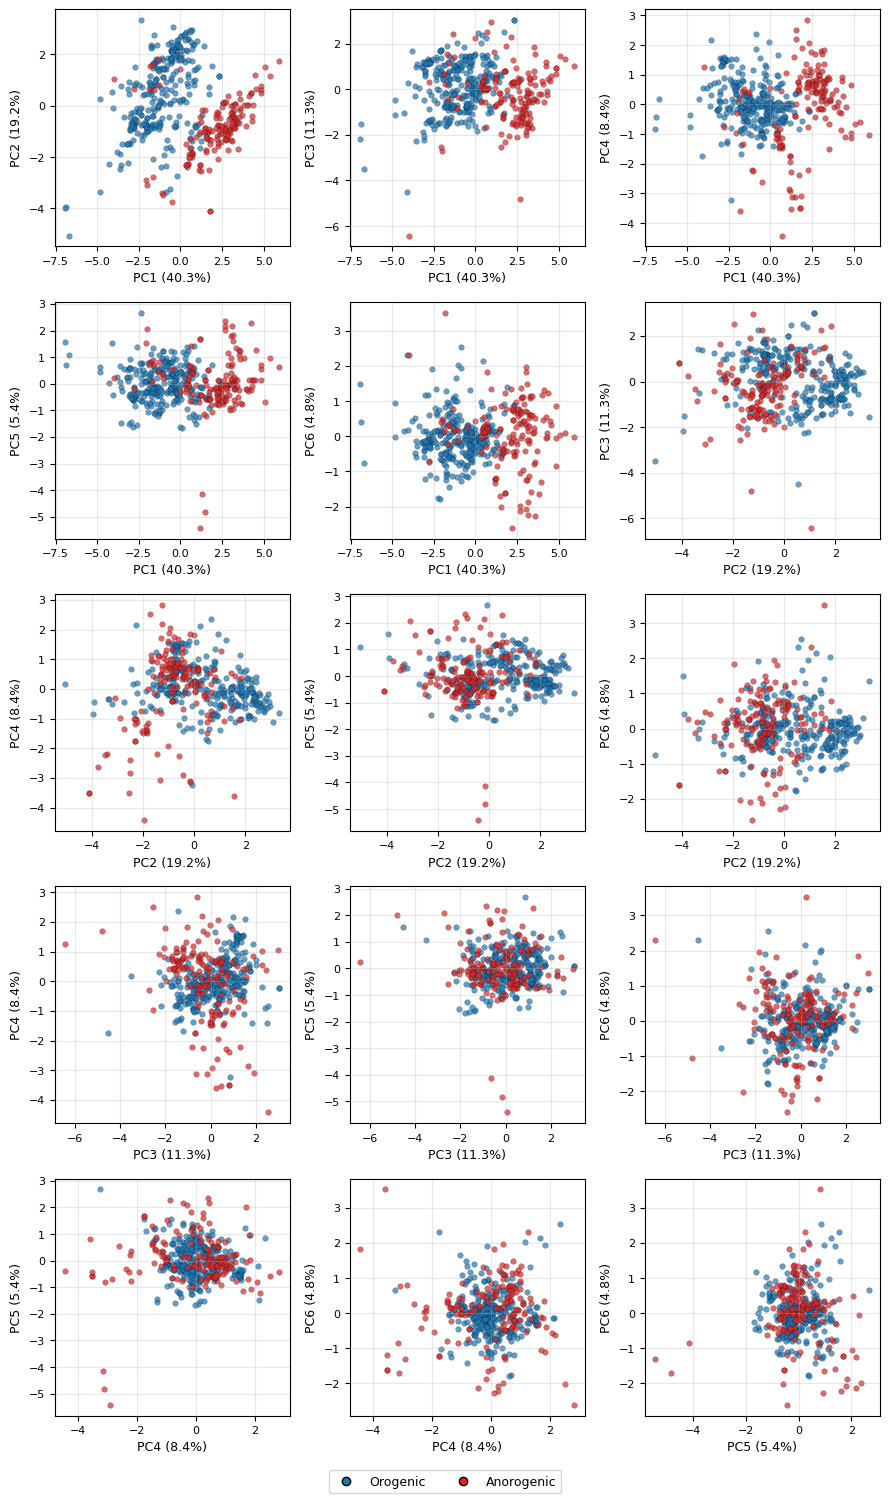

Saved: C:\Users\d67199rs\Desktop\Lamproite\figures\08_PCA_Score_Space.png


<Figure size 640x480 with 0 Axes>

In [22]:
# =============================================================================
# PCA score plots for first six principal components
# =============================================================================

from itertools import combinations

scores = pd.DataFrame(pca.transform(X), columns=[f"PC{i+1}" for i in range(len(ELEMENTS))])
scores = pd.concat([df[META], scores], axis=1)

pcs = [f"PC{i}" for i in range(1, 7)]
pairs = list(combinations(pcs, 2))

series_colours = {"Orogenic": "tab:blue", "Anorogenic": "tab:red"}

fig, axes = plt.subplots(5, 3, figsize=(9, 15.2))
axes = axes.flatten()

for ax, (pcx, pcy) in zip(axes, pairs):
    for series, colour in series_colours.items():
        sub = scores[scores["Series"] == series]
        ax.scatter(sub[pcx], sub[pcy], s=16, color=colour, alpha=0.7, edgecolor="black", linewidth=0.2)

    ix = int(pcx[2:]) - 1
    iy = int(pcy[2:]) - 1

    ax.set_xlabel(f"{pcx} ({pca.explained_variance_ratio_[ix]*100:.1f}%)", fontsize=9)
    ax.set_ylabel(f"{pcy} ({pca.explained_variance_ratio_[iy]*100:.1f}%)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", color="tab:blue", markeredgecolor="black", markersize=6, label="Orogenic"),
    Line2D([0], [0], marker="o", linestyle="", color="tab:red", markeredgecolor="black", markersize=6, label="Anorogenic")
]

fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=True, bbox_to_anchor=(0.5, 0.01),fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()
outpath = FIGURE_DIR / "08_PCA_Score_Space.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
print(f"Saved: {outpath}")

## 5. Principal Component 1 Distribution

Evaluate the distribution of principal component 1 scores for the orogenic and anorogenic lamproites to assess the degree of separation along the dominant axis of variance.

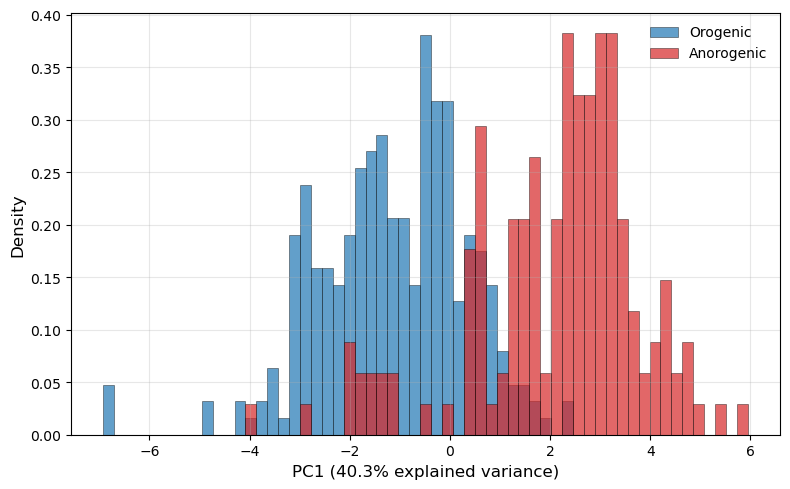

Saved: C:\Users\d67199rs\Desktop\Lamproite\figures\09_PC1_Distribution.png


In [24]:
# =============================================================================
# PC1 score distribution
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(scores["PC1"].min(), scores["PC1"].max(), 60)
series_colours = {"Orogenic": "tab:blue", "Anorogenic": "tab:red"}

for series, colour in series_colours.items():
    ax.hist(scores.loc[scores["Series"] == series, "PC1"], bins=bins, density=True, alpha=0.7, color=colour, edgecolor="black", linewidth=0.4, label=series)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% explained variance)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()

outpath = FIGURE_DIR / "09_PC1_Distribution.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outpath}")

## 6. K Means Cluster Optimisation

Evaluate the intrinsic clustering structure of the dataset using K means clustering across a range of cluster numbers. Cluster performance is assessed using four complementary metrics: inertia, silhouette score, Davies–Bouldin index and Calinski–Harabasz index.

In [32]:
# =============================================================================
# K means cluster evaluation
# =============================================================================

cluster_results = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X)

    cluster_results.append({
        "k": k,
        "Inertia": kmeans.inertia_,
        "Silhouette": silhouette_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels)
    })

df_metrics = pd.DataFrame(cluster_results)

df_metrics["Δ_Inertia"] = df_metrics["Inertia"].diff().abs()

display(
    df_metrics.round({
        "Inertia": 1,
        "Δ_Inertia": 1,
        "Silhouette": 3,
        "Davies_Bouldin": 3,
        "Calinski_Harabasz": 2
    })
)

,k,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,Δ_Inertia
0,2,3757.6,0.299,1.395,186.56,NaN
1,3,3052.9,0.267,1.331,165.56,704.7
2,4,2679.5,0.283,1.406,145.95,373.4
3,5,2449.6,0.286,1.408,129.79,229.9
4,6,2278.4,0.265,1.438,117.98,171.2
5,7,2158.0,0.228,1.479,107.64,120.3
6,8,1995.2,0.232,1.448,104.65,162.8


## 7. Final K Means Clustering

Fit the final K means model using the optimal number of clusters identified during cluster optimisation and assign each analysis to its corresponding cluster for subsequent comparison and geochemical characterisation.

In [38]:
# =============================================================================
# Final K means clustering
# =============================================================================
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
df["Cluster"] = kmeans.fit_predict(X)
cluster_summary = pd.crosstab(df["Cluster"], df["Series"])
cluster_summary["Analyses"] = cluster_summary.sum(axis=1)
cluster_summary["Anorogenic"] = cluster_summary.apply(
    lambda r: f"{r['Anorogenic']} ({100*r['Anorogenic']/r['Analyses']:.1f}%)", axis=1
)

cluster_summary["Orogenic"] = cluster_summary.apply(
    lambda r: f"{r['Orogenic']} ({100*r['Orogenic']/r['Analyses']:.1f}%)", axis=1
)

cluster_summary = cluster_summary[["Analyses", "Anorogenic", "Orogenic"]]
display(cluster_summary)

Series,Analyses,Anorogenic,Orogenic
Cluster,,,
0,166,142 (85.5%),24 (14.5%)
1,279,14 (5.0%),265 (95.0%)


In [42]:
# =============================================================================
# Cluster composition by location
# =============================================================================

location_clusters = pd.crosstab(df["Location"], df["Cluster"])

location_clusters["Analyses"] = location_clusters.sum(axis=1)

location_series = df.groupby("Location")["Series"].first()
location_clusters["Series"] = location_series

location_clusters["Cluster 0"] = location_clusters.apply(
    lambda r: f"{r[0]} ({100*r[0]/r['Analyses']:.1f}%)", axis=1
)

location_clusters["Cluster 1"] = location_clusters.apply(
    lambda r: f"{r[1]} ({100*r[1]/r['Analyses']:.1f}%)", axis=1
)

location_clusters = (
    location_clusters[["Series", "Analyses", "Cluster 0", "Cluster 1"]]
    .sort_values(["Series", "Analyses"], ascending=[True, False])
)

display(location_clusters)
outpath = EXPORT_DIR / "06_KMeans_Location_Cluster_Summary.csv"

location_clusters.to_csv(outpath)

print(f"Saved: {outpath}")

Cluster,Series,Analyses,Cluster 0,Cluster 1
Location,,,,
Australia,Anorogenic,100,99 (99.0%),1 (1.0%)
India,Anorogenic,17,12 (70.6%),5 (29.4%)
China (Yangtze Block),Anorogenic,13,13 (100.0%),0 (0.0%)
Antarctica,Anorogenic,11,10 (90.9%),1 (9.1%)
Russia,Anorogenic,8,1 (12.5%),7 (87.5%)
"USA (Leucite Hills, Wyoming)",Anorogenic,5,5 (100.0%),0 (0.0%)
Norway,Anorogenic,2,2 (100.0%),0 (0.0%)
Spain (Betics),Orogenic,74,0 (0.0%),74 (100.0%)
Macedonia,Orogenic,64,0 (0.0%),64 (100.0%)


Saved: C:\Users\d67199rs\Desktop\Lamproite\exports\06_KMeans_Location_Cluster_Summary.csv


In [52]:
# =============================================================================
# Geochemical characteristics of K means clusters
# =============================================================================

df_raw = pd.read_csv(PROCESSED_DIR / "Modelling_Dataset.csv")
df_raw["Cluster"] = df["Cluster"].values

cluster_summary = pd.DataFrame(index=ELEMENTS)

for c in sorted(df_raw["Cluster"].unique()):
    sub = df_raw.loc[df_raw["Cluster"] == c, ELEMENTS]
    cluster_summary[f"Cluster {c} Median"] = sub.median().round(0).astype(int)
    cluster_summary[f"Cluster {c} Q1"] = sub.quantile(0.25).round(0).astype(int)
    cluster_summary[f"Cluster {c} Q3"] = sub.quantile(0.75).round(0).astype(int)

display(cluster_summary)

outpath = EXPORT_DIR / "07_KMeans_Cluster_Geochemistry.csv"
cluster_summary.to_csv(outpath)

print(f"Saved: {outpath}")

,Cluster 0 Median,Cluster 0 Q1,Cluster 0 Q3,Cluster 1 Median,Cluster 1 Q1,Cluster 1 Q3
K,70517,42916,85334,56530,46901,66865
Ti,27572,18357,34331,8152,6983,9441
Sr,1366,1089,1684,829,623,1149
P,5215,3884,6851,4669,3491,6044
Rb,296,225,373,344,228,566
Nb,132,110,166,35,25,47
Ba,6446,3068,11248,2076,1526,2884
Zr,1167,943,1429,545,358,770
Ce,402,309,551,208,126,282
Th,23,20,31,62,25,119


Saved: C:\Users\d67199rs\Desktop\Lamproite\exports\07_KMeans_Cluster_Geochemistry.csv
